In [52]:
import pandas as pd
from src.utils import load_env
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import textwrap
from matplotlib.ticker import MaxNLocator

from case_study.utils import blue_hex, yellow_hex, lt_blue_hex, red_hex, white_hex

env_vars = load_env()

In [53]:
# Global figure style (Style B: modern sans, soft panel, no hard axis lines)
# Applied once here -- every plot below inherits it automatically.
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.spines.bottom': False,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'medium',
    'figure.facecolor': 'none',
    'axes.facecolor': 'none',
    'savefig.facecolor': 'none',
    'axes.grid': True,
    'grid.color': '#e0e0dc',
    'grid.linewidth': 0.7,
    'axes.axisbelow': True,
    'xtick.color': '#444444',
    'ytick.color': '#444444',
    'xtick.major.size': 0,
    'ytick.major.size': 0,
})

In [54]:
input_path = f"{env_vars['RESULTS_DIR']}/cluster_embeddings/pckmeans/podcasts/mets_only_qwen_fe_clusters_225_w0.1.csv"
df = pd.read_csv(input_path)
df["doc_year"] = df["doc_year"].astype(int)

In [55]:
# Maps raw `channel` values in the sheet to properly formatted display names.
channel_display_names = {
    'mark levin podcast':                             'Mark Levin Podcast',
    'pod save america':                               'Pod Save America',
    'the dan bongino show':                           'The Dan Bongino Show',
    'the megyn kelly show':                           'The Megyn Kelly Show',
    'the meidastouch podcast':                        'MeidasTouch Podcast',
    'the michael moore podcast':                      'The Michael Moore Podcast',
    'the sean hannity show':                          'The Sean Hannity Show',
    'the tucker carlson show':                        'The Tucker Carlson Show',
    'the young turks':                                'The Young Turks',
    'why is this happening the chris hayes podcast':  'Chris Hayes Podcast',
}

# usage: add a display-name column, or just relabel on the fly in a plot
df['channel_display'] = df['channel'].map(channel_display_names)

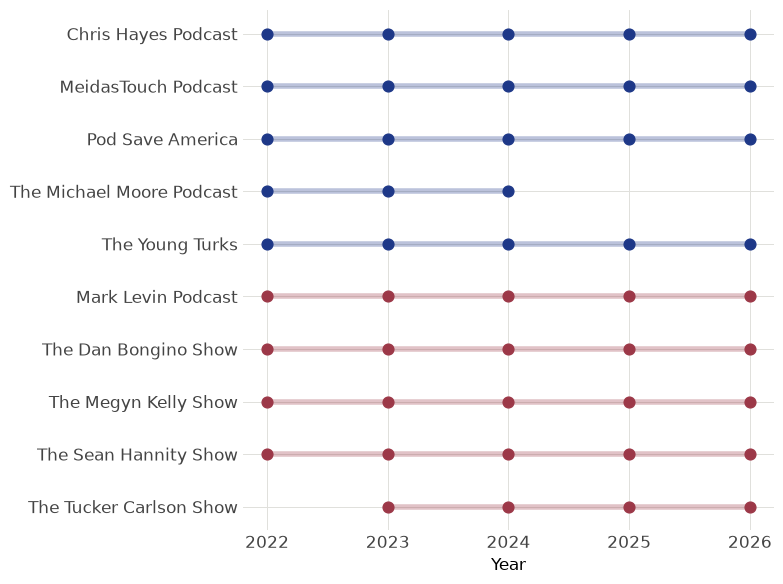

In [56]:
channel_order = (df[['channel_display','polarity']].drop_duplicates()
                  .sort_values(['polarity','channel_display'])['channel_display'].tolist())
def plot_channel_coverage_timeline(df):
    cov = df.groupby(['channel_display','doc_year','polarity']).size().reset_index(name='n')
    fig, ax = plt.subplots(figsize=(8, 0.45*len(channel_order)+1.5))
    for i, ch in enumerate(channel_order):
        sub = cov[cov.channel_display==ch]
        color = blue_hex if sub['polarity'].iloc[0]=='left' else red_hex
        years = sorted(sub['doc_year'].unique())
        ax.plot([years[0], years[-1]], [i,i], color=color, alpha=0.3, linewidth=4, solid_capstyle='round')
        ax.scatter(years, [i]*len(years), color=color, s=60, zorder=3)
    ax.set_yticks(range(len(channel_order)))
    ax.set_yticklabels(channel_order)
    ax.set_xlabel('Year')
    # ax.set_title('Channel coverage: which years have data')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.invert_yaxis()
    plt.tight_layout()
    return fig

fig = plot_channel_coverage_timeline(df)
fig.savefig('figures/channel_coverage.png', dpi=300, bbox_inches='tight', transparent=True)

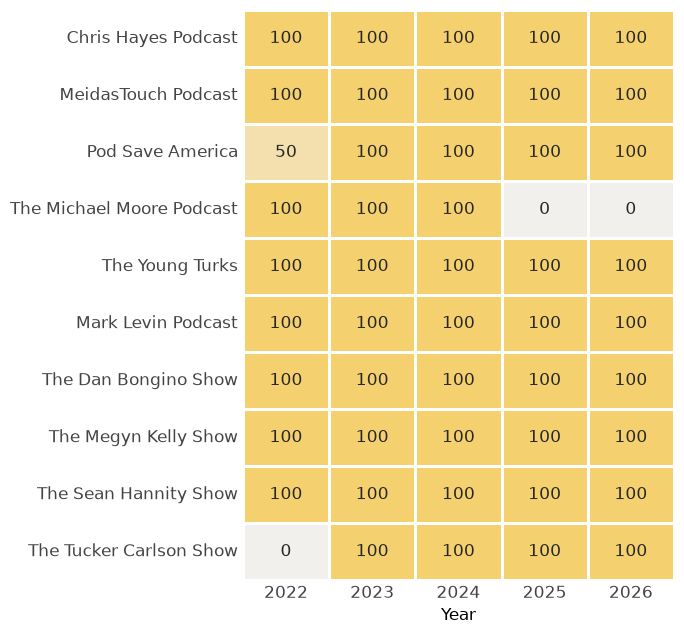

In [57]:
def plot_channel_year_heatmap(df):
    ct = df.groupby(['channel_display','doc_year']).size().unstack(fill_value=0)
    ct = ct.loc[channel_order]
    fig, ax = plt.subplots(figsize=(7, 0.45*len(channel_order)+2))
    cmap = sns.light_palette(yellow_hex, as_cmap=True)
    sns.heatmap(ct, annot=True, fmt='d', cmap=cmap, ax=ax, cbar=False,
                linewidths=2, linecolor='white')
    ax.set_xlabel('Year')
    ax.set_ylabel('')

    # ax.set_title('Sampling coverage: mentions per channel per year')
    plt.tight_layout()
    return fig

fig = plot_channel_year_heatmap(df)
fig.savefig('figures/met_coverage.png', dpi=300, bbox_inches='tight', transparent=True)


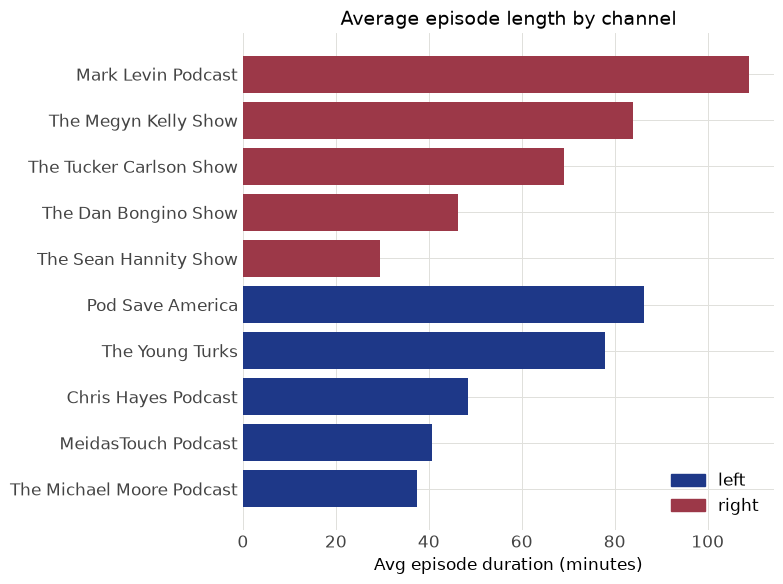

In [73]:
def plot_avg_episode_duration_by_channel(df):
    # de-dupe to one row per episode first so channels with more metaphor rows
    # per episode don't get double-counted in the average
    ep = df.drop_duplicates(subset=['channel_display','episode'])[['channel_display','polarity','duration']].copy()
    ep['duration_min'] = ep['duration'] / 60
    avg = ep.groupby(['channel_display','polarity'])['duration_min'].mean().reset_index()
    avg = avg.sort_values(['polarity', 'duration_min'])

    fig, ax = plt.subplots(figsize=(8,6))
    colors = [blue_hex if p=='left' else red_hex for p in avg['polarity']]
    ax.barh(avg['channel_display'], avg['duration_min'], color=colors)
    ax.set_xlabel('Avg episode duration (minutes)')
    ax.set_title('Average episode length by channel')
    ax.legend(handles=[mpatches.Patch(color=blue_hex, label='left'), mpatches.Patch(color=red_hex, label='right')],
              frameon=False, loc='lower right')
    plt.tight_layout()
    return fig

fig = plot_avg_episode_duration_by_channel(df)
fig.savefig('figures/duration_by_channel.png', dpi=300, bbox_inches='tight', transparent=True)

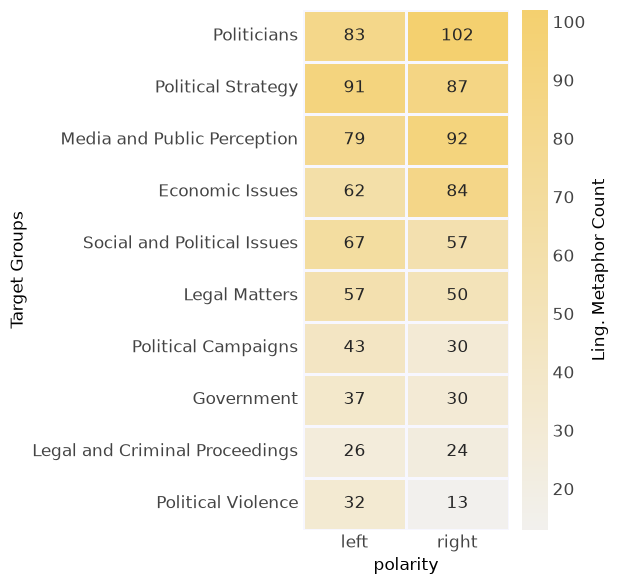

In [59]:
def plot_topic_heatmap(df, top_n=15):
    sub = df[df['target_group'] != 'Other']
    top_groups = sub['target_group'].value_counts().head(top_n).index
    sub = sub[sub['target_group'].isin(top_groups)]
    ct = pd.crosstab(sub['target_group'], sub['polarity'])
    ct = ct.loc[top_groups]
    fig, ax = plt.subplots(figsize=(6, 0.4*top_n+2))
    cmap = sns.light_palette(yellow_hex, as_cmap=True)  # neutral ramp, matches project palette, not purple
    sns.heatmap(ct, annot=True, fmt='d', cmap=cmap,
                ax=ax, cbar_kws={'label':'Ling. Metaphor Count'},
                linewidths=2, linecolor=white_hex)
    # ax.set_xlabel("")
    ax.set_ylabel("Target Groups")
    ax.tick_params(axis='both', length=0)
    plt.tight_layout()
    return fig

tg_heatmap = plot_topic_heatmap(df, 10)
tg_heatmap.savefig('figures/tg_heatmap.png', dpi=300, bbox_inches='tight', transparent=True)

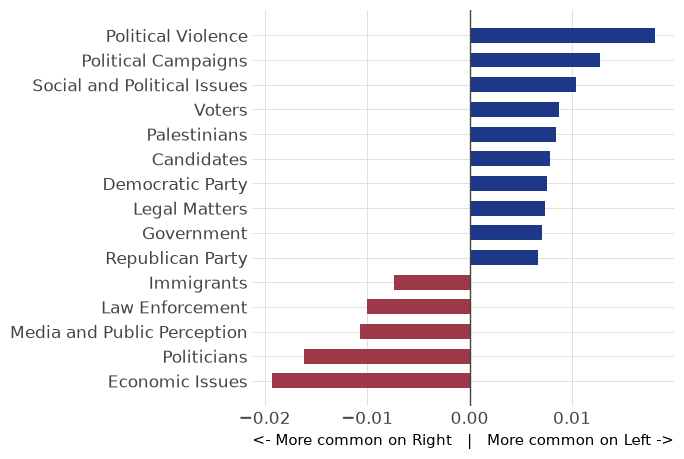

In [69]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.spines.left': False, 'axes.spines.bottom': False,
    'figure.facecolor': 'none', 'axes.facecolor': 'none', 'savefig.facecolor': 'none',
    'axes.grid': True, 'grid.color': '#e0e0dc', 'grid.linewidth': 0.7,
    'axes.axisbelow': True, 'xtick.major.size': 0, 'ytick.major.size': 0,
    'savefig.bbox': 'tight',   # applies to Jupyter's inline display too, not just explicit savefig()
})

def plot_divisive_target_groups(df, top_n=15):
    sub = df[df['target_group'] != 'Other']
    counts = sub.groupby(['target_group','polarity']).size().unstack(fill_value=0)
    totals = sub['polarity'].value_counts()
    share_left = counts.get('left',0)/totals.get('left',1)
    share_right = counts.get('right',0)/totals.get('right',1)
    diff = share_left - share_right
    top = diff.abs().sort_values(ascending=False).head(top_n).index
    plot_df = diff.loc[top].sort_values()

    fig, ax = plt.subplots(figsize=(7, 0.25*len(plot_df)+1))
    colors = [red_hex if v<0 else blue_hex for v in plot_df]
    ax.barh(plot_df.index, plot_df.values, color=colors, height=0.6)
    ax.axvline(0, color='#444444', linewidth=1.0)
    ax.set_xlabel('<- More common on Right   |   More common on Left ->', fontsize=11)
    plt.tight_layout()
    return fig

fig = plot_divisive_target_groups(df, top_n=15)
fig.savefig('figures/divisive_target_groups.png', dpi=300, bbox_inches='tight', transparent=True)

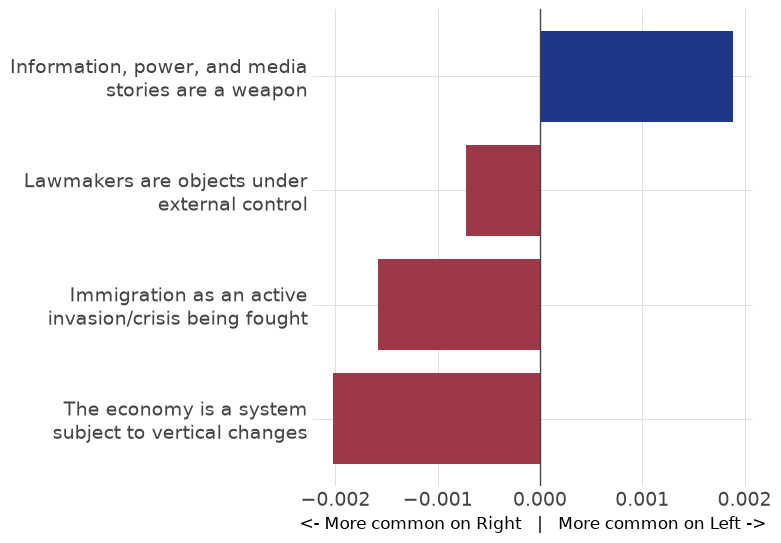

In [71]:
cluster_labels = {
    1: "Lawmakers are objects under external control",
    3: "The economy is a system subject to vertical changes",
    19: "Information, power, and media stories are a weapon",
    25: "Immigration as an active invasion/crisis being fought"
}

def plot_annotated_clusters(df, cluster_labels, wrap_width=30, fontsize=14):
    counts = df.groupby(['clust_imp_rank', 'polarity']).size().unstack(fill_value=0)
    totals = df['polarity'].value_counts()
    diff = counts.get('left', 0)/totals.get('left', 1) - counts.get('right', 0)/totals.get('right', 1)
    plot_df = pd.DataFrame({'diff': diff.loc[list(cluster_labels)]})
    plot_df['label'] = ["\n".join(textwrap.wrap(cluster_labels[c], wrap_width)) for c in plot_df.index]
    plot_df = plot_df.sort_values('diff')

    fig, ax = plt.subplots(figsize=(8, 0.9*len(plot_df)+2))
    ax.barh(plot_df['label'], plot_df['diff'], color=[red_hex if v < 0 else blue_hex for v in plot_df['diff']])
    ax.axvline(0, color='#444444', linewidth=1.0)
    ax.set_xlabel('<- More common on Right   |   More common on Left ->', fontsize=fontsize-2)
    ax.tick_params(axis='both', labelsize=fontsize)
    plt.tight_layout()
    return fig

ann_cm_pol = plot_annotated_clusters(df, cluster_labels)
ann_cm_pol.savefig('figures/ann_cm_polarity.png', dpi=300, bbox_inches='tight', transparent=True)

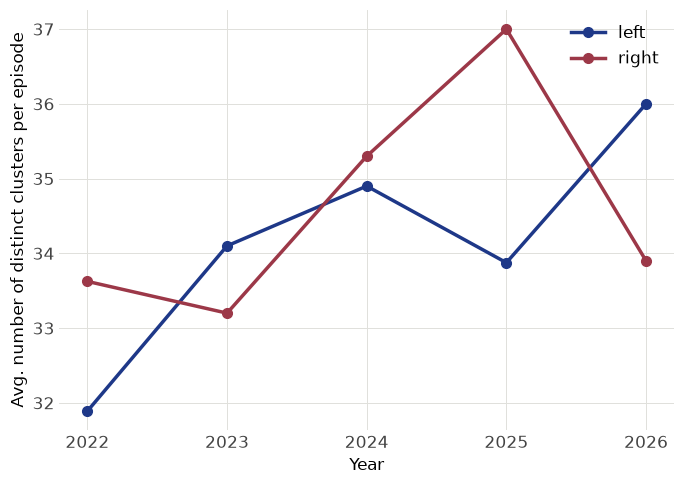

In [62]:

def plot_polarity_diversity_trend(df, method='avg_per_episode'):
    if method == 'avg_per_episode':
        # average over episode
        div = df.groupby(['episode', 'doc_year','polarity'])['cluster'].nunique().reset_index(name='n_clusters')
        # average over year / polarity
        trend = div.groupby(['doc_year', 'polarity'])['n_clusters'].mean().reset_index()
        ylabel = 'Avg. number of distinct clusters per episode'
    else:
        raise ValueError("method must be 'avg_per_channel' or 'full_coverage_only'")

    fig, ax = plt.subplots(figsize=(7,5))
    for pol, color in [('left', blue_hex), ('right', red_hex)]:
        s = trend[trend.polarity==pol].sort_values('doc_year')
        ax.plot(s['doc_year'], s['n_clusters'], marker='o', label=pol, color=color, linewidth=2.5, markersize=7)
    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend(frameon=False)
    plt.tight_layout()
    return fig

fig = plot_polarity_diversity_trend(df)
fig.savefig('figures/diversity_trend.png', dpi=300, bbox_inches='tight', transparent=True)

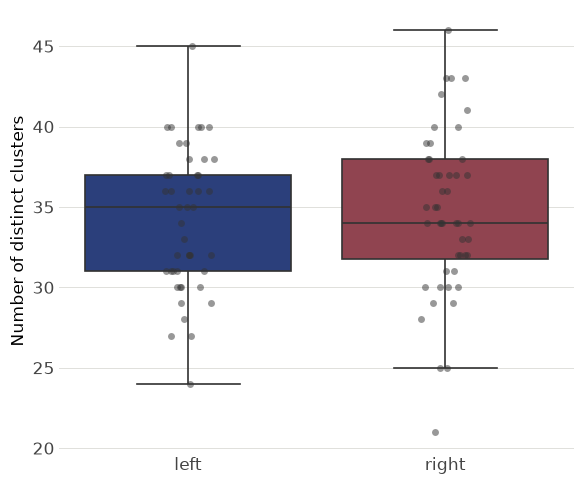

In [63]:
def plot_diversity_boxplot(df):
    div = df.groupby(['episode','doc_year','polarity'])['cluster'].nunique().reset_index(name='n_clusters')
    fig, ax = plt.subplots(figsize=(6,5))
    sns.boxplot(data=div, x='polarity', y='n_clusters', hue='polarity', order=['left','right'],
                palette={'left':blue_hex,'right':red_hex}, ax=ax, showfliers=False, legend=False,
                linewidth=1.2)
    sns.stripplot(data=div, x='polarity', y='n_clusters', order=['left','right'],
                  color='#333333', alpha=0.5, jitter=True, ax=ax, size=5)
    ax.set_xlabel('')
    ax.set_ylabel('Number of distinct clusters')
    plt.tight_layout()
    return fig

fig = plot_diversity_boxplot(df)
fig.savefig('figures/diversity_boxplot.png', dpi=300, bbox_inches='tight', transparent=True)

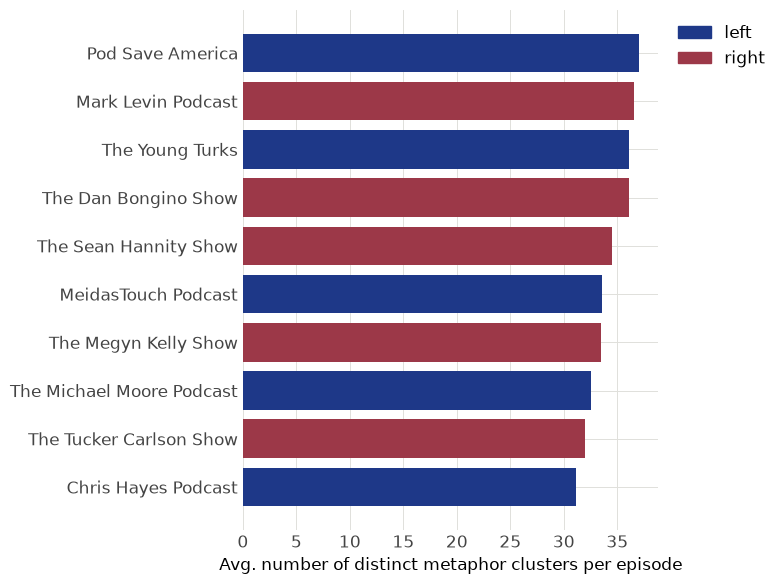

In [64]:
from matplotlib.patches import Patch

def plot_avg_diversity_by_channel(df):
    div = df.groupby(['episode', 'channel_display','polarity'])['cluster'].nunique().reset_index(name='n_clusters')
    avg = div.groupby(['channel_display','polarity'])['n_clusters'].mean().reset_index()
    avg = avg.sort_values('n_clusters')
    fig, ax = plt.subplots(figsize=(8,6))
    colors = [blue_hex if p=='left' else red_hex for p in avg['polarity']]
    ax.barh(avg['channel_display'], avg['n_clusters'], color=colors)
    ax.set_xlabel('Avg. number of distinct metaphor clusters per episode')
    ax.legend(handles=[Patch(color=blue_hex, label='left'), Patch(color=red_hex, label='right')],
              frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1.0))
    plt.tight_layout()
    return fig

fig = plot_avg_diversity_by_channel(df)
fig.savefig('figures/avg_diversity_by_channel.png', dpi=300, bbox_inches='tight', transparent=True)